In [1]:
import anndata as ad
import numpy as np
import matplotlib.pyplot as plt

# Load data

In [2]:
adata = ad.read_h5ad("C:/Users/willi/Downloads/TotalX_HEK293T.h5ad")
adata

c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\anndata\_core\aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 33787 × 46173
    var: 'gene_ids', 'feature_types', 'genome', 'GeneName', 'gene_id', 'biotype'

# Biotypes

In [3]:
adata.var['biotype'].value_counts()

biotype
protein_coding     19313
lncRNA             18551
misc_RNA            2220
snRNA               1910
miRNA               1877
snoRNA               942
tRNA                 535
IG_V_pseudogene      187
IG_V_gene            145
TR_V_gene            107
histone_RNA           95
TR_J_gene             79
scaRNA                49
IG_D_gene             37
TR_V_pseudogene       33
Mt_tRNA               22
IG_J_gene             18
IG_C_gene             14
IG_C_pseudogene        9
TR_C_gene              6
TR_D_gene              5
sRNA                   5
virus                  5
TR_J_pseudogene        4
IG_J_pseudogene        3
scRNA                  1
vault_RNA              1
Name: count, dtype: int64

# Cell filtering

- Follow `fig 1b` code for HEK data
- filters out cells with < 5000 total counts
- equivalent to < 0.1 mean counts over all genes
- retains 11,945 cells

In [4]:
# equivalent to cells with mean counts < 0.1
min_umi_threshold = 5000

# total UMIs per cell
total_cell_counts = np.array(adata.X.sum(axis=1)).flatten()

# Filter cells
adata_cell_filter = adata[total_cell_counts >= min_umi_threshold].copy()
print(f"Filtering retains {adata_cell_filter.n_obs} cells with >= {min_umi_threshold} total UMIs (counts)")

Filtering retains 11945 cells with >= 5000 total UMIs (counts)


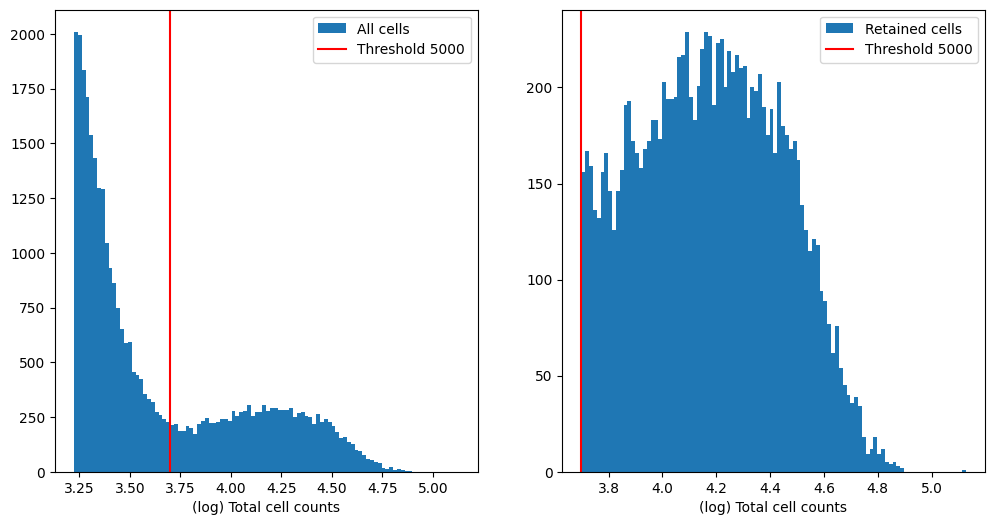

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].hist(np.log10(total_cell_counts), bins=100, label="All cells")
axs[0].axvline(np.log10(min_umi_threshold), color="red", linestyle="-", label=f"Threshold {min_umi_threshold}")
axs[0].set_xlabel("(log) Total cell counts")
axs[0].legend()
axs[1].hist(np.log10(total_cell_counts[total_cell_counts >= min_umi_threshold]), bins=100, label="Retained cells")
axs[1].axvline(np.log10(min_umi_threshold), color="red", linestyle="-", label=f"Threshold {min_umi_threshold}")
axs[1].set_xlabel("(log) Total cell counts")
axs[1].legend()
plt.show()

# Gene filtering

- no gene filtering done for HEK in paper
- for PBMC cells
    - miRNA are selected if expressed in at least 100 cells (and at least 2% in at least one cell type, but not applicable here as just one cell type)
    - mRNA are selected (from targets) if mean expression > 0.1 and expressed in at least 1% of cells

In [6]:
# select miRNA & pcRNA
mask_pcRNA = (adata.var['biotype'] == "protein_coding")
mask_miRNA = (adata.var['biotype'] == "miRNA")

counts_pcRNA = adata_cell_filter.X[:, mask_pcRNA]
counts_miRNA = adata_cell_filter.X[:, mask_miRNA]

# total_counts per miRNA & pcRNA
total_counts_pcRNA = np.array(counts_pcRNA.sum(axis=0)).flatten()
total_counts_miRNA = np.array(counts_miRNA.sum(axis=0)).flatten()

# cells detecting each miRNA & pcRNA
detected_pcRNA = np.array((counts_pcRNA > 0).sum(axis=0)).flatten()
detected_miRNA = np.array((counts_miRNA > 0).sum(axis=0)).flatten()

## Expression

In [7]:
thresholds = np.linspace(0, 100, 100)#np.logspace(0, 3, 10)
pcRNA_numbers = []
miRNA_numbers = []
for thresh in thresholds:
    pcRNA_numbers.append((total_counts_pcRNA > thresh).sum())
    miRNA_numbers.append((total_counts_miRNA > thresh).sum())

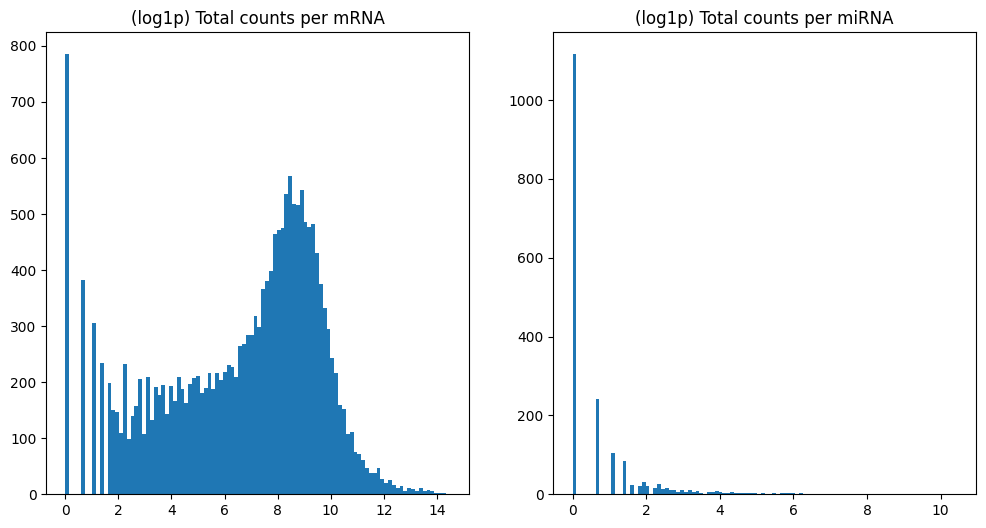

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].hist(np.log1p(total_counts_pcRNA), bins=100)
axs[0].set_title("(log1p) Total counts per mRNA")
axs[1].hist(np.log1p(total_counts_miRNA), bins=100)
axs[1].set_title("(log1p) Total counts per miRNA")
plt.show()

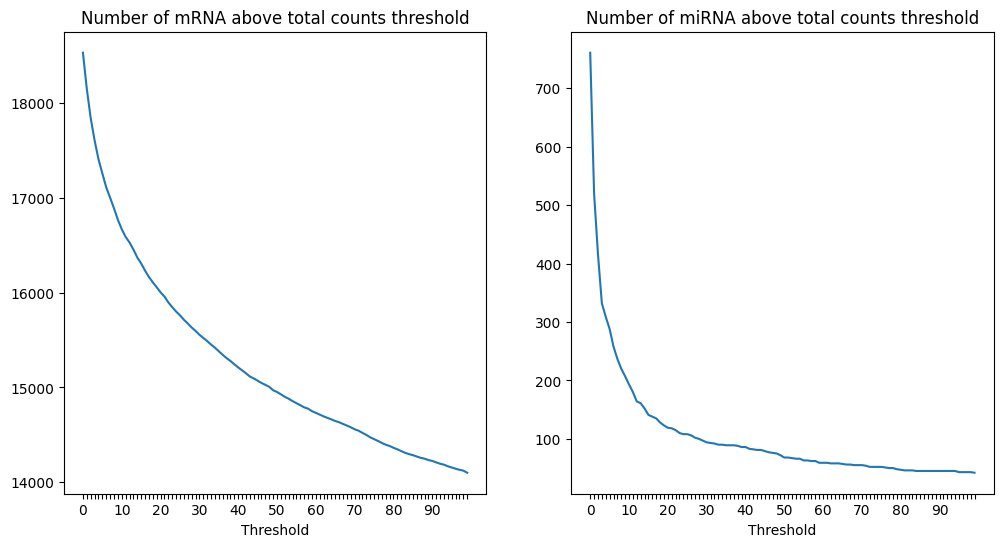

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
xticks = [int(x) if i % 10 == 0 else "" for i, x in enumerate(thresholds)]
axs[0].plot(pcRNA_numbers)
axs[0].set_title("Number of mRNA above total counts threshold")
axs[0].set_xticks(range(len(thresholds)))
axs[0].set_xticklabels(xticks)
axs[0].set_xlabel("Threshold")
axs[1].plot(miRNA_numbers)
axs[1].set_title("Number of miRNA above total counts threshold")
axs[1].set_xticks(range(len(thresholds)))
axs[1].set_xticklabels(xticks)
axs[1].set_xlabel("Threshold")
plt.show()

## Detection

In [10]:
thresholds = np.linspace(0, 100, 100)#np.logspace(0, 3, 10)
pcRNA_numbers = []
miRNA_numbers = []
for thresh in thresholds:
    pcRNA_numbers.append((detected_pcRNA > thresh).sum())
    miRNA_numbers.append((detected_miRNA > thresh).sum())

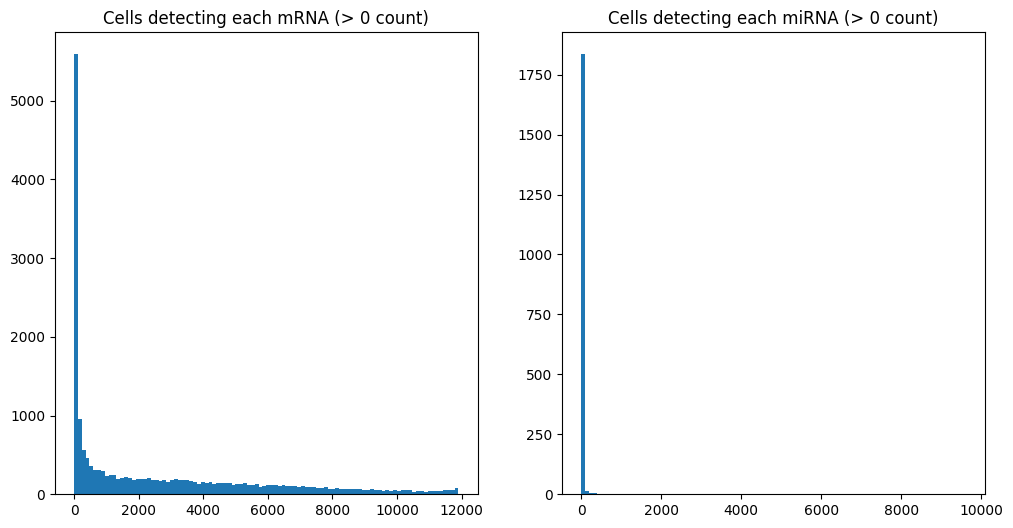

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].hist(detected_pcRNA, bins=100)
axs[0].set_title("Cells detecting each mRNA (> 0 count)")
axs[1].hist(detected_miRNA, bins=100)
axs[1].set_title("Cells detecting each miRNA (> 0 count)")
plt.show()

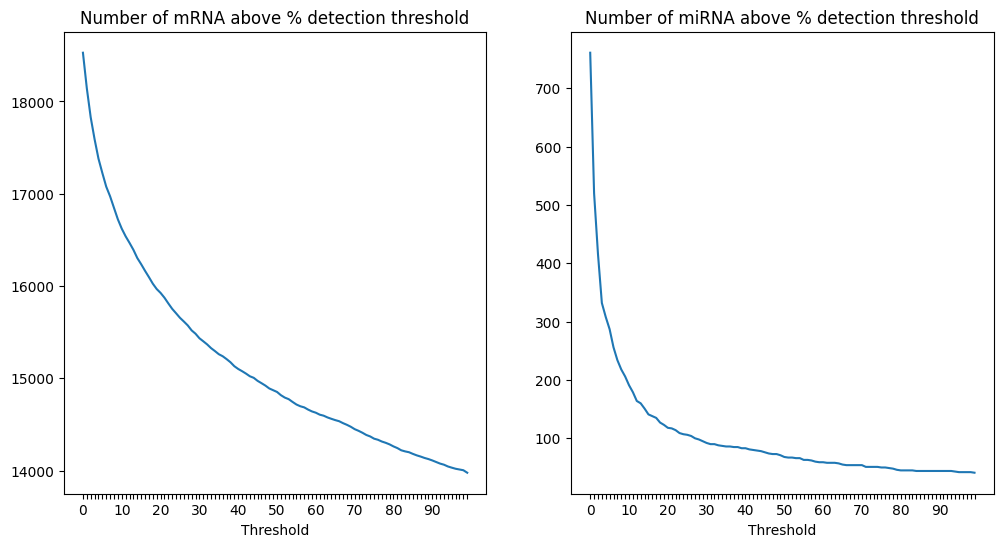

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
xticks = [int(x) if i % 10 == 0 else "" for i, x in enumerate(thresholds)]
axs[0].plot(pcRNA_numbers)
axs[0].set_title("Number of mRNA above % detection threshold")
axs[0].set_xticks(range(len(thresholds)))
axs[0].set_xticklabels(xticks)
axs[0].set_xlabel("Threshold")
axs[1].plot(miRNA_numbers)
axs[1].set_title("Number of miRNA above % detection threshold")
axs[1].set_xticks(range(len(thresholds)))
axs[1].set_xticklabels(xticks)
axs[1].set_xlabel("Threshold")
plt.show()

## Paper choices

In [13]:
# select miRNA detected in >= 100 cells
mask_miRNA = (detected_miRNA >= 100)
print(f"Selected {mask_miRNA.sum()} miRNA")

Selected 41 miRNA


In [14]:
# select mRNA detected in >= 1% cells and mean expression >= 0.1 (basically same if using log(x + 1) or not)
mask_pcRNA_1 = (detected_pcRNA >= adata_cell_filter.n_obs * 0.01)
mask_pcRNA_2 = (total_counts_pcRNA >= adata_cell_filter.n_obs * 0.1)
mask_pcRNA = mask_pcRNA_1 & mask_pcRNA_2
print(f"Selected {mask_pcRNA.sum()} mRNA \n{mask_pcRNA_1.sum()} selected via detection >= 1% \n{mask_pcRNA_2.sum()} selected via mean expression >= 0.1")

Selected 10307 mRNA 
13723 selected via detection >= 1% 
10307 selected via mean expression >= 0.1


In [15]:
# subset mRNA
adata_pcRNA = adata_cell_filter[:, adata_cell_filter.var['biotype'] == "protein_coding"].copy()
adata_pcRNA = adata_pcRNA[:, mask_pcRNA].copy()

# subset miRNA
adata_miRNA = adata_cell_filter[:, adata_cell_filter.var['biotype'] == "miRNA"].copy()
adata_miRNA = adata_miRNA[:, mask_miRNA].copy()

In [16]:
adata_pcRNA

AnnData object with n_obs × n_vars = 11945 × 10307
    var: 'gene_ids', 'feature_types', 'genome', 'GeneName', 'gene_id', 'biotype'

In [17]:
adata_miRNA

AnnData object with n_obs × n_vars = 11945 × 41
    var: 'gene_ids', 'feature_types', 'genome', 'GeneName', 'gene_id', 'biotype'

In [18]:
# save adatas
#adata_pcRNA.write_h5ad("TotalX_HEK293T_pcRNA.h5ad")
#adata_miRNA.write_h5ad("TotalX_HEK293T_miRNA.h5ad")

### Display

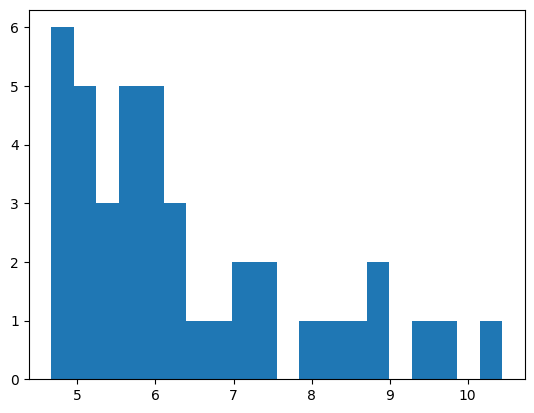

In [19]:
plt.hist(np.log1p(total_counts_miRNA[mask_miRNA]), bins=20);

In [20]:
# mean expression in range [0.1, 2]
(np.exp(5) - 1) / adata_cell_filter.n_obs, (np.exp(10) - 1) / adata_cell_filter.n_obs

(np.float64(0.012340992808922277), np.float64(1.8439067220432581))

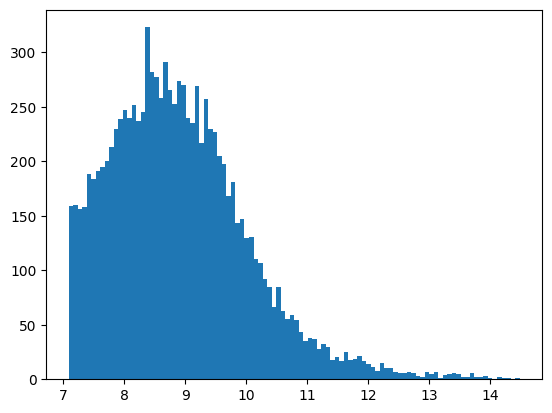

In [21]:
plt.hist(np.log1p(total_counts_pcRNA[mask_pcRNA]), bins=100);

In [22]:
# mean expression in range [0.1, 100]
(np.exp(7) - 1) / adata_cell_filter.n_obs, (np.exp(14) - 1) / adata_cell_filter.n_obs

(np.float64(0.0917231610237303), np.float64(100.6783829355192))

In [23]:
# log(x + 1) > 0.1 roughly same as x > 0.1
np.exp(0.1) - 1

np.float64(0.10517091807564771)

# Capture

In [24]:
import seaborn as sns
import pandas as pd

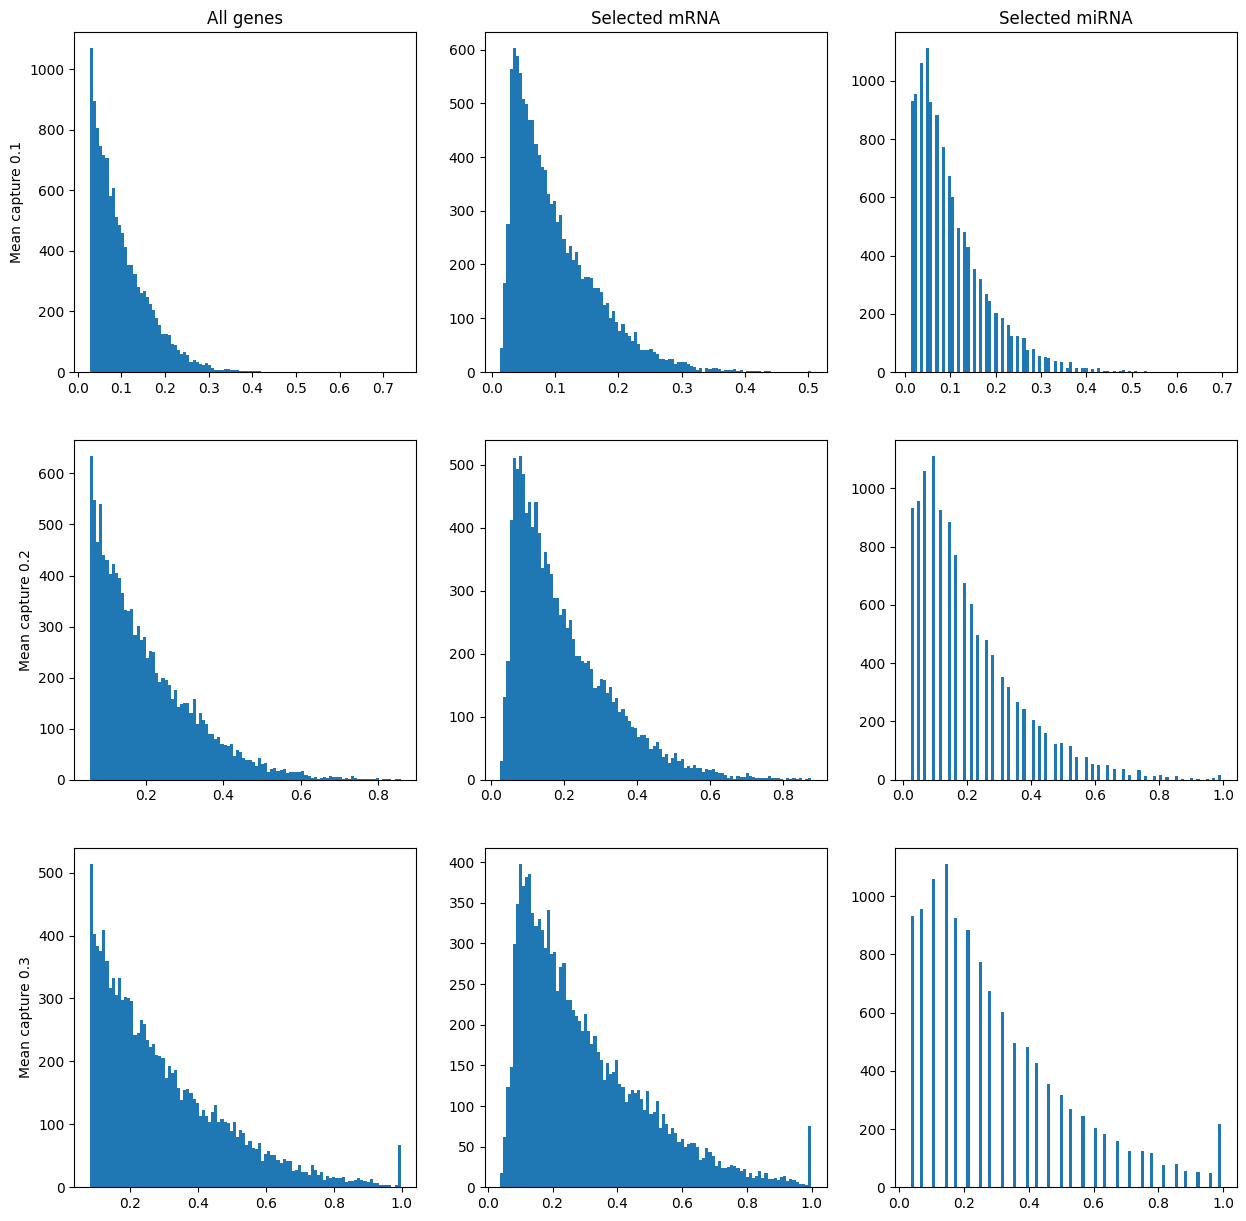

In [25]:
fig, axs = plt.subplots(3, 3, figsize=(15, 15))

for i, beta_mean in enumerate([0.1, 0.2, 0.3]):

    for j, ada in enumerate([adata_cell_filter, adata_pcRNA, adata_miRNA]):

        total_cell_counts = np.array(ada.X.sum(axis=1)).flatten()
        total_counts_mean = total_cell_counts.mean()
        beta = np.array(total_cell_counts / total_counts_mean) * beta_mean
        beta[beta >= 1] = beta[beta < 1].max()
        beta[beta <= 0] = beta[beta > 0].min()

        axs[i, j].hist(beta, bins=100)

    axs[i, 0].set_ylabel(f"Mean capture {beta_mean}")

axs[0, 0].set_title("All genes")
axs[0, 1].set_title("Selected mRNA")
axs[0, 2].set_title("Selected miRNA")
plt.show()

In [26]:
beta_mean = 0.2
total_cell_counts = np.array(adata_pcRNA.X.sum(axis=1)).flatten()
total_counts_mean = total_cell_counts.mean()
beta = np.array(total_cell_counts / total_counts_mean) * beta_mean
beta[beta >= 1] = beta[beta < 1].max()
beta[beta <= 0] = beta[beta > 0].min()
beta_20 = beta

In [27]:
#np.savetxt("TotalX_HEK293T_capture.txt", beta_20)

In [28]:
beta_mean = 0.1
total_cell_counts = np.array(adata_pcRNA.X.sum(axis=1)).flatten()
total_counts_mean = total_cell_counts.mean()
beta = np.array(total_cell_counts / total_counts_mean) * beta_mean
beta[beta >= 1] = beta[beta < 1].max()
beta[beta <= 0] = beta[beta > 0].min()
beta_10 = beta

In [ ]:
#np.savetxt("TotalX_HEK293T_capture_10.txt", beta_10)

In [30]:
beta_mean = 0.3
total_cell_counts = np.array(adata_pcRNA.X.sum(axis=1)).flatten()
total_counts_mean = total_cell_counts.mean()
beta = np.array(total_cell_counts / total_counts_mean) * beta_mean
beta[beta >= 1] = beta[beta < 1].max()
beta[beta <= 0] = beta[beta > 0].min()
beta_30 = beta

In [31]:
#np.savetxt("TotalX_HEK293T_capture_30.txt", beta_30)

0.19998895 0.29925907


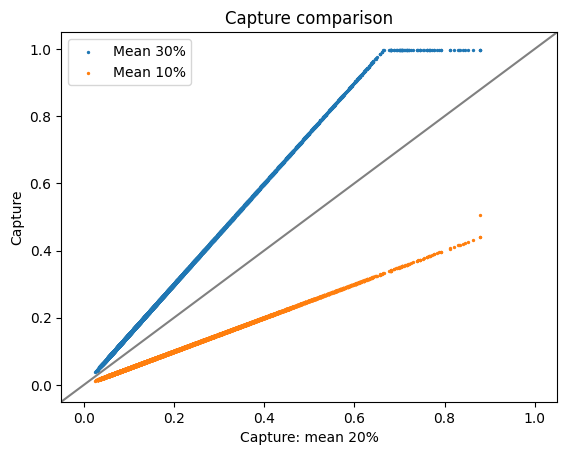

In [32]:
print(np.mean(beta_20), np.mean(beta_30))
plt.scatter(beta_20, beta_30, s=2, label="Mean 30%")
plt.scatter(beta_20, beta_10, s=2, label="Mean 10%")
plt.xlabel("Capture: mean 20%")
plt.ylabel("Capture")
plt.title("Capture comparison")
plt.axline([0, 0], [1, 1], color="grey")
plt.legend()
plt.show()

# Appendix

## BayNorm capture

In [26]:
def mad(x):
    """
    Exact replication of R's mad():
    mad(x, constant = 1.4826, center = median(x))
    """
    x = np.asarray(x)
    x = x[~np.isnan(x)]  # match R's na.rm = TRUE behavior
    med = np.median(x)
    return 1.4826 * np.median(np.abs(x - med))

In [27]:
def Check_input(Data):
    """
    Minimal placeholder for the R Check_input().
    Ensures Data is a numeric pandas DataFrame.
    """
    if not isinstance(Data, pd.DataFrame):
        Data = pd.DataFrame(Data)
    return Data.astype(float)

In [33]:
def BetaFun(Data, MeanBETA):
    # Set matrix as object for input data
    Data = Check_input(Data)

    # Column sums
    xx = Data.sum(axis=0)

    # Normcount <- t(t(Data)/xx) * mean(xx)
    Normcount = Data.div(xx, axis=1) * xx.mean()

    # Row means
    means = Normcount.mean(axis=1)
    lmeans = np.log(means)

    # Row-wise median and MAD of log(Normcount + 1)
    log_norm = np.log(Normcount + 1)

    med = log_norm.apply(np.median, axis=1)
    mad_vals = log_norm.apply(mad, axis=1)

    bound = med + 3 * mad_vals

    # Row-wise max
    maxlogGene = log_norm.max(axis=1)

    # ind <- which(maxlogGene < bound)
    ind = maxlogGene[maxlogGene < bound].index

    # dropout rate per gene
    dropout = (Data == 0).sum(axis=1) / Data.shape[1]

    # Select_ind <- intersect(ind, which(dropout < 0.35))
    Select_ind = ind.intersection(dropout[dropout < 0.35].index)

    Selected_genes = Select_ind.to_numpy()

    # temppp <- colSums(Data[Select_ind, ])
    temppp = Data.loc[Select_ind].sum(axis=0)

    # BETA <- temppp/mean(temppp) * MeanBETA
    BETA = temppp / temppp.mean() * MeanBETA

    # Truncate BETA values
    if (BETA >= 1).any():
        BETA[BETA >= 1] = BETA[BETA < 1].max()

    if (BETA <= 0).any():
        BETA[BETA <= 0] = BETA[BETA > 0].min()

    # names(BETA) <- colnames(Data)
    BETA.index = Data.columns

    return {
        "BETA": BETA,
        "Selected_genes": Selected_genes
    }

In [56]:
(adata_miRNA.X.sum(axis=1) == 0).sum()

np.int64(287)

In [ ]:
BetaFun(adata_miRNA.X.toarray(), 0.2)

## Capture

In [ ]:
total_cell_counts = np.array(adata_cell_filter.X.sum(axis=1)).flatten()
total_counts_mean = total_cell_counts.mean()
beta_all = np.array(total_cell_counts / total_counts_mean) * beta_mean

In [292]:
total_cell_counts = np.array(adata_pcRNA.X.sum(axis=1)).flatten()
total_counts_mean = total_cell_counts.mean()
beta_pcRNA = np.array(total_cell_counts / total_counts_mean) * beta_mean

In [293]:
total_cell_counts = np.array(adata_miRNA.X.sum(axis=1)).flatten()
total_counts_mean = total_cell_counts.mean()
beta_miRNA = np.array(total_cell_counts / total_counts_mean) * beta_mean

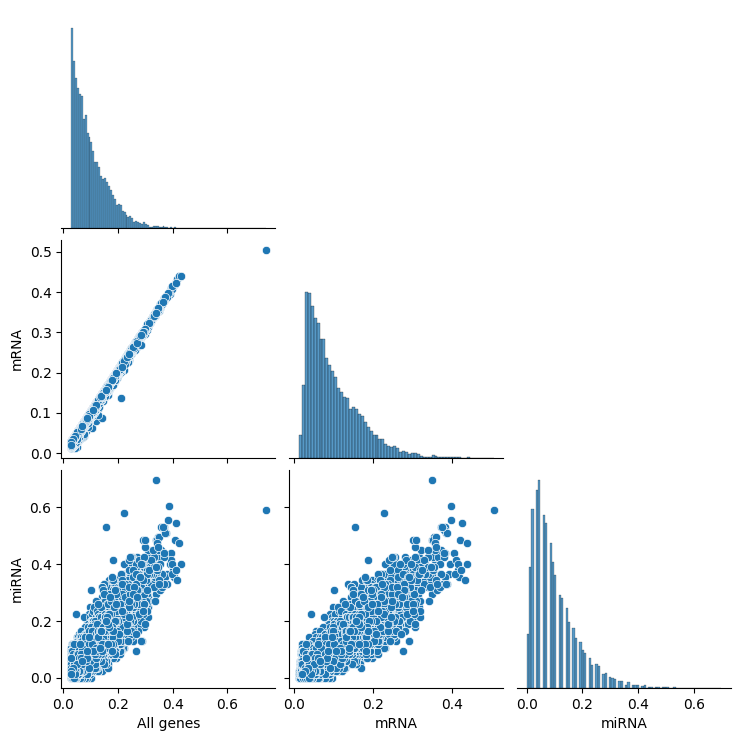

In [259]:
sns.pairplot(
    pd.DataFrame(
        {
            "All genes": beta_all,
            "mRNA": beta_pcRNA,
            "miRNA": beta_miRNA
        }
    ),
    corner=True
)

In [267]:
beta_FIB = np.loadtxt("../../Moment-equations/Real-Data-2/Capture/beta_FIB.txt")

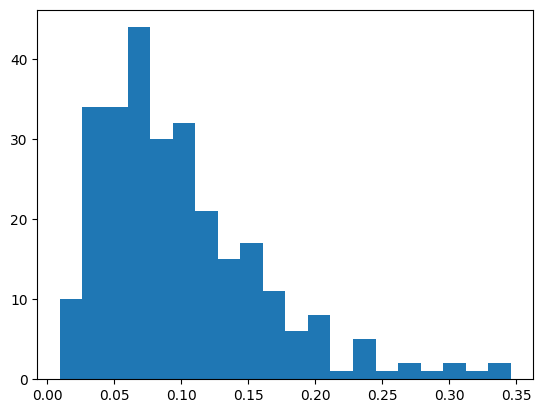

In [270]:
plt.hist(beta_FIB, bins=20);

## Bootstrap work

Existing code struggles with larger cell sizes

In [100]:
import scipy

In [108]:
from sklearn.utils import resample

In [106]:
rng = np.random.default_rng()

In [170]:
Xc = adata_pcRNA.X.tocsc()

In [190]:
s1 = Xc[:, 54]
s2 = Xc[:, 234]
sample = scipy.sparse.hstack([s1, s2])
sample

<Compressed Sparse Column sparse matrix of dtype 'float32'
	with 2460 stored elements and shape (11945, 2)>

In [210]:
#for i in range(1000):
resample(sample)

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 2445 stored elements and shape (11945, 2)>

In [209]:
rng.choice(sample.toarray(), size=(1000,))

array([[1., 0.],
       [0., 0.],
       [0., 1.],
       ...,
       [0., 0.],
       [0., 0.],
       [0., 1.]], shape=(1000, 2), dtype=float32)

### New vs Old Bootstrap

Not significantly faster, but avoids large dense matrices

In [1]:
import pandas as pd
import anndata as ad
import numpy as np

In [ ]:
from SDP_interaction_inference.dataset import Dataset

: 

In [3]:
def construct_dataset(mirna_sample, mrna_dataset, beta, resamples):

    # size
    cells, gene_pairs = mrna_dataset.shape

    # construct paired count dataframe
    counts_df = pd.DataFrame(
        index = [f"Gene-pair-{i}" for i in range(gene_pairs)],
        columns = [f"Cell-{j}" for j in range(cells)]
    )

    # fill with pairs
    for i in range(gene_pairs):
        gene_i = mirna_sample[:, 0]
        gene_j = mrna_dataset[:, i]
        gene_pair_ij = list(zip(gene_i, gene_j))
        counts_df.iloc[i] = gene_pair_ij

    # construct dataset object
    data = Dataset()
    data.count_dataset = counts_df
    data.cells = cells
    data.gene_pairs = gene_pairs

    # settings
    data.resamples = resamples

    # set capture
    data.beta = beta

    return data

G = 100

# load pcRNA
adata_pcRNA = ad.read_h5ad("TotalX_HEK293T_pcRNA.h5ad")

# load miRNA
adata_miRNA = ad.read_h5ad("TotalX_HEK293T_miRNA.h5ad")

# load capture
beta = np.loadtxt("TotalX_HEK293T_capture.txt")

# select data
data_miRNA = adata_miRNA[:, 0].X.toarray()
data_pcRNA = adata_pcRNA[:, :G].X.toarray() # restrict for testing

# construct dataset of miRNA paired with mRNA
dataset_SDP = construct_dataset(
    data_miRNA,
    data_pcRNA,
    beta,
    1000
)

# bootstrap
dataset_SDP.confidence = 0.95
dataset_SDP.bootstrap(
    d=3,
    tqdm_disable=False
)

100%|██████████| 100/100 [01:57<00:00,  1.18s/it]


In [2]:
from SDP_interaction_inference.dataset import SparseDataset

In [3]:
G = 1

# load pcRNA
adata_pcRNA = ad.read_h5ad("TotalX_HEK293T_pcRNA.h5ad")

# load miRNA
adata_miRNA = ad.read_h5ad("TotalX_HEK293T_miRNA.h5ad")

# load capture
beta = np.loadtxt("TotalX_HEK293T_capture.txt")

dataset_SDP = SparseDataset()

#dataset_SDP.miRNA_dataset = adata_miRNA[:, 0].X
#dataset_SDP.pcRNA_dataset = adata_pcRNA.X
#dataset_SDP.beta = beta
#dataset_SDP.pair_indices = [[0, i] for i in range(adata_pcRNA.n_vars)]
#dataset_SDP.cells = adata_pcRNA.n_obs
#dataset_SDP.gene_pairs = adata_pcRNA.n_vars

dataset_SDP.construct_dataset(
    adata_miRNA[:, 0],
    adata_pcRNA[:, :G],
    beta
)

dataset_SDP.bootstrap(
    d=3,
    tqdm_disable=False
)

100%|██████████| 1/1 [00:01<00:00,  1.68s/it]
